# 08.1 - Model Comparison (WELFake)

Loads all four WELFake models and evaluates on the held-out test set.
Outputs are saved to `reports/08_1_welfake_comparison/`.


In [1]:
import json
from pathlib import Path
from IPython.display import display

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports" / "08_1_welfake_comparison"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")


In [2]:
X_test = joblib.load(DATA_DIR / "welfake/X_test_tfidf.pkl")
y_test = np.array(joblib.load(DATA_DIR / "welfake/y_test.pkl"))

models = {
    "Naive Bayes": joblib.load(MODELS_DIR / "nb_welfake_model.pkl"),
    "Logistic Regression": joblib.load(MODELS_DIR / "lr_welfake_model.pkl"),
    "SVM (LinearSVC)": joblib.load(MODELS_DIR / "svm_welfake_model.pkl"),
    "Random Forest": joblib.load(MODELS_DIR / "rf_welfake_model.pkl"),
}

print("X_test:", X_test.shape)
for name, model in models.items():
    print(name, "n_features_in_=", getattr(model, "n_features_in_", None))
    if getattr(model, "n_features_in_", X_test.shape[1]) != X_test.shape[1]:
        raise ValueError(f"{name} is incompatible with X_test feature count.")


X_test: (10812, 5000)
Naive Bayes n_features_in_= 5000
Logistic Regression n_features_in_= 5000
SVM (LinearSVC) n_features_in_= 5000
Random Forest n_features_in_= 5000


In [3]:
report_dirs = {
    "Naive Bayes": ROOT / "reports" / "14_welfake_naive_bayes" / "metrics.json",
    "Logistic Regression": ROOT / "reports" / "15_welfake_logistic_regression" / "metrics.json",
    "SVM (LinearSVC)": ROOT / "reports" / "13_welfake_svm" / "metrics.json",
    "Random Forest": ROOT / "reports" / "16_welfake_random_forest" / "metrics.json",
}

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    train_time = None
    if report_dirs[name].exists():
        with open(report_dirs[name], "r", encoding="utf-8") as f:
            train_time = json.load(f).get("training_time_seconds")

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "training_time_seconds": train_time,
    })

comparison = pd.DataFrame(rows).sort_values("f1_weighted", ascending=False)
comparison.to_csv(REPORT_DIR / "test_metrics.csv", index=False)
display(comparison)


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
3,Random Forest,0.949871,0.949909,0.949871,0.949875,2107.186074
2,SVM (LinearSVC),0.945154,0.945158,0.945154,0.945149,NaN
1,Logistic Regression,0.943396,0.943396,0.943396,0.943393,NaN
0,Naive Bayes,0.840640,0.841131,0.840640,0.840459,4.722743


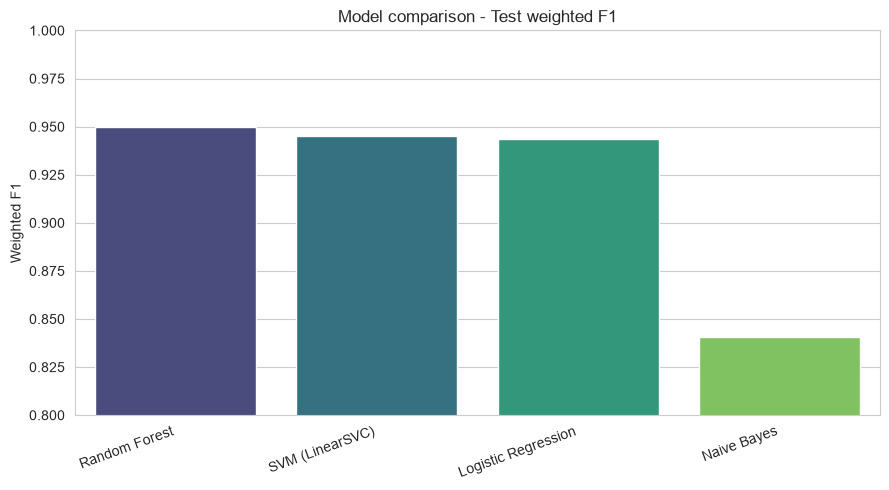

In [4]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison, x="model", y="f1_weighted", hue="model", palette="viridis")
plt.ylim(0.80, 1.00)
plt.title("Model comparison - Test weighted F1")
plt.xlabel("")
plt.ylabel("Weighted F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "comparison_f1_score.png", dpi=150, bbox_inches="tight")
plt.show()

with open(REPORT_DIR / "comparison_summary.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_model": comparison.iloc[0]["model"],
            "best_f1_weighted": float(comparison.iloc[0]["f1_weighted"]),
            "rows": comparison.to_dict(orient="records"),
        },
        f,
        indent=2,
        ensure_ascii=False,
    )
